# GoEmotions manifold null controls

This notebook tests whether the observed alignment between emotion-label centroids and VAD distances is stronger than several null models.

It runs four null controls:

1. **Shuffle emotion labels across comments**: destroys the comment-to-label relation while preserving label counts.
2. **Shuffle VAD coordinates across labels**: preserves embedding centroids, but destroys label-to-VAD correspondence.
3. **Random Gaussian centroids**: replaces label centroids with Gaussian vectors of the same shape.
4. **Random centroids sampled from comments regardless of label**: preserves the real embedding distribution and each label's centroid sample size, but destroys label identity.

The observed result is shown against the null distributions using Spearman correlation between pairwise embedding/manifold distances and pairwise VAD distances.

Tiny warning from the void: if the observed score does not beat these controls, the manifold story is probably just a very fancy way of rediscovering noise with better fonts.


In [1]:
# =========================
# Configuration
# =========================

from pathlib import Path

# Change these if your folder layout differs.
DATA_DIR = Path(r"D:/pyprojects/m4r/data/goemotions")
EMBEDDINGS_PATH = DATA_DIR / "manifold_outputs" / "embeddings.npy"
METADATA_PATH = DATA_DIR / "manifold_outputs" / "metadata.csv"
VAD_CSV_PATH = DATA_DIR / "emotion_label_vad_starter.csv"

# Plot/table outputs go here.
OUT_DIR = Path(r"D:/pyprojects/m4r/new_plots/null_controls")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Distance choices:
#   MANIFOLD_DISTANCE = "cosine" or "knn_geodesic"
#   GROUND_TRUTH_SPACE = "valence", "arousal", "dominance", "VA", or "VAD"
MANIFOLD_DISTANCE = "cosine"
GROUND_TRUTH_SPACE = "VAD"

# For knn_geodesic only.
# "auto" searches for the smallest connected k for each graph.
KNN_K = "auto"
KNN_GRAPH_METRIC = "angular"  # "angular", "cosine", or "euclidean"

# PCA_DIM_FOR_ANALYSIS:
#   0 means use the raw embedding dimensions.
#   50 is much faster and usually enough for null controls.
#   The real result and every null are computed in the same feature space.
PCA_DIM_FOR_ANALYSIS = 50

# Null iterations. Raise this to 1000+ for final reporting.
# Start lower while debugging, because waiting for permutations is how humans invented despair.
N_NULL = 500
SEED = 42

# For random comment-centroid null.
# False means each pseudo-centroid samples comments without replacement internally.
# Different pseudo-centroids may still reuse the same comments.
RANDOM_CENTROIDS_REPLACE = False

# For Gaussian null.
# True matches each embedding dimension's empirical centroid mean/std.
# False uses standard normal vectors.
GAUSSIAN_MATCH_CENTROID_MEAN_STD = True

print("Output folder:", OUT_DIR)


Output folder: D:\pyprojects\m4r\new_plots\null_controls


In [2]:
# =========================
# Imports and helpers
# =========================

import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.stats import spearmanr, pearsonr, kendalltau

from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors


VAD_SPACES = {
    "VAD": ["valence", "arousal", "dominance"],
    "VA": ["valence", "arousal"],
    "valence": ["valence"],
    "arousal": ["arousal"],
    "dominance": ["dominance"],
}


def upper_values(D):
    idx = np.triu_indices(D.shape[0], k=1)
    return D[idx]


def corr_row(truth_D, rep_D):
    truth = upper_values(truth_D)
    rep = upper_values(rep_D)
    mask = np.isfinite(truth) & np.isfinite(rep)
    truth = truth[mask]
    rep = rep[mask]
    
    if len(truth) < 3 or np.std(truth) == 0 or np.std(rep) == 0:
        return {
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "kendall_tau": np.nan,
            "kendall_p": np.nan,
            "n_pairs": int(len(truth)),
        }
    
    sr = spearmanr(truth, rep)
    pr = pearsonr(truth, rep)
    kt = kendalltau(truth, rep)
    return {
        "spearman_rho": float(sr.statistic),
        "spearman_p": float(sr.pvalue),
        "pearson_r": float(pr.statistic),
        "pearson_p": float(pr.pvalue),
        "kendall_tau": float(kt.statistic),
        "kendall_p": float(kt.pvalue),
        "n_pairs": int(len(truth)),
    }


def angular_pairwise(X):
    Xn = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
    sims = np.clip(Xn @ Xn.T, -1.0, 1.0)
    return np.arccos(sims)


def pairwise_rep_distance(X, method):
    if method == "cosine":
        return pairwise_distances(X, metric="cosine")
    if method == "angular":
        return angular_pairwise(X)
    if method == "euclidean":
        return pairwise_distances(X, metric="euclidean")
    raise ValueError(f"Unknown direct distance method: {method}")


def build_symmetric_knn_graph(X, k, metric):
    n = X.shape[0]
    if k >= n:
        raise ValueError(f"k must be smaller than n. Got k={k}, n={n}")
    
    if metric == "angular":
        Xn = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
        nbrs.fit(Xn)
        _, indices = nbrs.kneighbors(Xn)
        indices = indices[:, 1:]
        
        rows = np.repeat(np.arange(n), k)
        cols = indices.ravel()
        sims = np.sum(Xn[rows] * Xn[cols], axis=1)
        vals = np.arccos(np.clip(sims, -1.0, 1.0))
    else:
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric=metric)
        nbrs.fit(X)
        distances, indices = nbrs.kneighbors(X)
        distances = distances[:, 1:]
        indices = indices[:, 1:]
        
        rows = np.repeat(np.arange(n), k)
        cols = indices.ravel()
        vals = distances.ravel()
    
    G = csr_matrix((vals, (rows, cols)), shape=(n, n))
    return G.maximum(G.T)


def connected_k(X, metric, k_max=None):
    n = X.shape[0]
    if k_max is None:
        k_max = n - 1
    upper = min(k_max, n - 1)
    
    for k in range(1, upper + 1):
        G = build_symmetric_knn_graph(X, k=k, metric=metric)
        n_components, _ = connected_components(G, directed=False)
        if n_components == 1:
            return k, G
    
    raise ValueError(f"Graph did not become connected up to k={upper}")


def geodesic_distance(X, k_value="auto", metric="angular"):
    if k_value == "auto":
        actual_k, G = connected_k(X, metric=metric)
        n_components = 1
    else:
        actual_k = int(k_value)
        G = build_symmetric_knn_graph(X, k=actual_k, metric=metric)
        n_components, _ = connected_components(G, directed=False)
    
    D = dijkstra(csgraph=G, directed=False, return_predecessors=False)
    return D, actual_k, int(n_components)


def representation_distance(X):
    if MANIFOLD_DISTANCE == "cosine":
        return pairwise_rep_distance(X, "cosine"), None, None
    if MANIFOLD_DISTANCE == "knn_geodesic":
        return geodesic_distance(X, k_value=KNN_K, metric=KNN_GRAPH_METRIC)
    raise ValueError("MANIFOLD_DISTANCE must be 'cosine' or 'knn_geodesic'")


def vad_distance_from_array(vad_array, space):
    cols = VAD_SPACES[space]
    col_idx = [{"valence": 0, "arousal": 1, "dominance": 2}[c] for c in cols]
    return pairwise_distances(vad_array[:, col_idx], metric="euclidean")


def empirical_p_values(null_values, observed):
    null_values = np.asarray(null_values, dtype=float)
    null_values = null_values[np.isfinite(null_values)]
    if len(null_values) == 0 or not np.isfinite(observed):
        return np.nan, np.nan, np.nan
    
    # For this experiment, a stronger real result means a larger positive rho.
    p_greater = (np.sum(null_values >= observed) + 1) / (len(null_values) + 1)
    
    # Two-sided-ish absolute-value test, useful if you only care about magnitude.
    p_abs = (np.sum(np.abs(null_values) >= abs(observed)) + 1) / (len(null_values) + 1)
    
    percentile = 100.0 * np.mean(null_values <= observed)
    return float(p_greater), float(p_abs), float(percentile)


def check_config():
    if GROUND_TRUTH_SPACE not in VAD_SPACES:
        raise ValueError(f"Unknown GROUND_TRUTH_SPACE: {GROUND_TRUTH_SPACE}")
    if MANIFOLD_DISTANCE not in {"cosine", "knn_geodesic"}:
        raise ValueError("MANIFOLD_DISTANCE must be 'cosine' or 'knn_geodesic'")
    if KNN_GRAPH_METRIC not in {"angular", "cosine", "euclidean"}:
        raise ValueError("KNN_GRAPH_METRIC must be 'angular', 'cosine', or 'euclidean'")
    if N_NULL < 10:
        warnings.warn("N_NULL is very small. Fine for smoke tests, silly for conclusions.")
        
check_config()


In [3]:
# =========================
# Load data
# =========================

X_raw = np.load(EMBEDDINGS_PATH)
metadata = pd.read_csv(METADATA_PATH)
vad_df = pd.read_csv(VAD_CSV_PATH)

required_meta = {"label_name", "label_idx"}
missing_meta = required_meta - set(metadata.columns)
if missing_meta:
    raise ValueError(f"metadata.csv is missing columns: {sorted(missing_meta)}")

required_vad = {"label_name", "valence", "arousal", "dominance"}
missing_vad = required_vad - set(vad_df.columns)
if missing_vad:
    raise ValueError(f"VAD CSV is missing columns: {sorted(missing_vad)}")

for col in ["valence", "arousal", "dominance"]:
    vad_df[col] = pd.to_numeric(vad_df[col], errors="coerce")
if vad_df[["valence", "arousal", "dominance"]].isna().any().any():
    bad = vad_df[vad_df[["valence", "arousal", "dominance"]].isna().any(axis=1)]
    raise ValueError("Some VAD rows contain missing/non-numeric values:\n" + bad.to_string(index=False))

if len(X_raw) != len(metadata):
    raise ValueError(f"Embeddings and metadata lengths differ: {len(X_raw)} vs {len(metadata)}")

print("Embeddings:", X_raw.shape)
print("Metadata:", metadata.shape)
print("Labels:", metadata["label_name"].nunique())
metadata["label_name"].value_counts().sort_index().head()


Embeddings: (4997, 3072)
Metadata: (4997, 5)
Labels: 28


label_name
admiration    201
amusement     201
anger         201
annoyance     201
approval      201
Name: count, dtype: int64

In [4]:
# =========================
# Optional PCA preprocessing
# =========================

rng = np.random.default_rng(SEED)

if PCA_DIM_FOR_ANALYSIS and PCA_DIM_FOR_ANALYSIS > 0:
    n_components = min(PCA_DIM_FOR_ANALYSIS, X_raw.shape[0] - 1, X_raw.shape[1])
    pca = PCA(n_components=n_components, random_state=SEED)
    X = pca.fit_transform(X_raw)
    print(f"Using PCA feature space: {X.shape}")
    print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")
else:
    X = X_raw
    print(f"Using raw feature space: {X.shape}")

embedding_dim_used = X.shape[1]


Using PCA feature space: (4997, 50)
Explained variance: 0.354


In [5]:
# =========================
# Build real label centroids and VAD table
# =========================

def make_label_table(metadata, vad_df):
    rows = []
    for label_name, group in metadata.groupby("label_name", sort=True):
        rows.append({
            "label_name": label_name,
            "label_idx": int(group["label_idx"].iloc[0]),
            "n_comments": int(len(group)),
        })
    label_df = pd.DataFrame(rows)
    label_df = label_df.merge(
        vad_df[["label_name", "valence", "arousal", "dominance"]],
        on="label_name",
        how="left",
    )
    if label_df[["valence", "arousal", "dominance"]].isna().any().any():
        missing = label_df.loc[label_df["valence"].isna(), "label_name"].tolist()
        raise ValueError(f"Missing VAD coordinates for labels: {missing}")
    return label_df


def make_centroids_from_metadata(X, metadata, label_order):
    centroids = []
    for label in label_order:
        idx = metadata.index[metadata["label_name"].eq(label)].to_numpy()
        if len(idx) == 0:
            raise ValueError(f"No rows found for label: {label}")
        centroids.append(X[idx].mean(axis=0))
    return np.vstack(centroids)


label_df = make_label_table(metadata, vad_df)
label_order = label_df["label_name"].tolist()
group_sizes = label_df["n_comments"].to_numpy(dtype=int)
real_vad = label_df[["valence", "arousal", "dominance"]].to_numpy(dtype=float)

real_centroids = make_centroids_from_metadata(X, metadata.reset_index(drop=True), label_order)

print("Real centroid matrix:", real_centroids.shape)
label_df


Real centroid matrix: (28, 50)


,label_name,label_idx,n_comments,valence,arousal,dominance
0,admiration,0,201,7.74,6.11,7.53
1,amusement,1,201,7.00,6.00,6.00
2,anger,2,201,2.85,7.17,5.55
3,annoyance,3,201,2.74,6.49,5.09
4,approval,4,201,7.33,5.83,6.89
5,caring,5,201,6.50,4.50,5.50
6,confusion,6,201,3.21,6.03,4.24
7,curiosity,7,201,6.08,5.82,5.42
8,desire,8,201,7.69,7.35,6.49
9,disappointment,9,201,2.39,4.92,3.29


In [6]:
# =========================
# Observed result
# =========================

real_rep_D, real_k, real_components = representation_distance(real_centroids)
real_truth_D = vad_distance_from_array(real_vad, GROUND_TRUTH_SPACE)
observed_stats = corr_row(real_truth_D, real_rep_D)
observed_rho = observed_stats["spearman_rho"]

print("Observed alignment")
print("------------------")
print(f"Distance method: {MANIFOLD_DISTANCE}")
if MANIFOLD_DISTANCE == "knn_geodesic":
    print(f"KNN graph metric: {KNN_GRAPH_METRIC}")
    print(f"KNN k: {real_k}")
    print(f"Connected components: {real_components}")
print(f"Ground truth: {GROUND_TRUTH_SPACE}")
print(f"Spearman rho: {observed_rho:.4f}")
print(f"Pearson r: {observed_stats['pearson_r']:.4f}")
print(f"Kendall tau: {observed_stats['kendall_tau']:.4f}")
print(f"Pairs: {observed_stats['n_pairs']}")


Observed alignment
------------------
Distance method: cosine
Ground truth: VAD
Spearman rho: 0.6168
Pearson r: 0.6021
Kendall tau: 0.4326
Pairs: 378


In [7]:
# =========================
# Null model generators
# =========================

label_to_code = {label: i for i, label in enumerate(label_order)}
n_labels = len(label_order)
n_comments = len(metadata)
metadata_reset = metadata.reset_index(drop=True)
original_codes = metadata_reset["label_name"].map(label_to_code).to_numpy(dtype=int)


def centroids_from_codes(X, codes, n_labels):
    sums = np.zeros((n_labels, X.shape[1]), dtype=np.float64)
    counts = np.bincount(codes, minlength=n_labels).astype(float)
    np.add.at(sums, codes, X)
    return sums / np.maximum(counts[:, None], 1.0)


def null_shuffle_emotion_labels(X, rng):
    # Preserves the original number of comments per label, but destroys which comments belong to which emotion.
    shuffled_codes = original_codes.copy()
    rng.shuffle(shuffled_codes)
    return centroids_from_codes(X, shuffled_codes, n_labels)


def null_shuffle_vad_coordinates(real_vad, rng):
    # Preserves the VAD coordinate cloud but breaks label-to-coordinate identity.
    return real_vad[rng.permutation(len(real_vad))]


def null_gaussian_centroids(real_centroids, rng):
    # Same number of labels and same dimensionality as the real centroid matrix.
    if GAUSSIAN_MATCH_CENTROID_MEAN_STD:
        mu = real_centroids.mean(axis=0, keepdims=True)
        sd = real_centroids.std(axis=0, ddof=1, keepdims=True)
        sd = np.maximum(sd, 1e-12)
        return rng.normal(loc=mu, scale=sd, size=real_centroids.shape)
    return rng.normal(size=real_centroids.shape)


def null_random_comment_centroids(X, group_sizes, rng):
    # For each label, sample the same number of comments as that real label, but ignore labels entirely.
    rows = []
    for size in group_sizes:
        replace = RANDOM_CENTROIDS_REPLACE or size > len(X)
        idx = rng.choice(len(X), size=int(size), replace=replace)
        rows.append(X[idx].mean(axis=0))
    return np.vstack(rows)


def score_centroids_against_real_vad(centroids):
    rep_D, actual_k, components = representation_distance(centroids)
    stats = corr_row(real_truth_D, rep_D)
    return stats["spearman_rho"], actual_k, components


def score_real_centroids_against_vad(vad_array):
    truth_D = vad_distance_from_array(vad_array, GROUND_TRUTH_SPACE)
    stats = corr_row(truth_D, real_rep_D)
    return stats["spearman_rho"]


In [8]:
# =========================
# Run null controls
# =========================

null_rows = []

for i in range(N_NULL):
    # 1. Shuffle labels across comments.
    C_label_shuffle = null_shuffle_emotion_labels(X, rng)
    rho, actual_k, components = score_centroids_against_real_vad(C_label_shuffle)
    null_rows.append({
        "iteration": i,
        "null_model": "shuffle_emotion_labels_across_comments",
        "spearman_rho": rho,
        "knn_k": actual_k,
        "graph_connected_components": components,
    })
    
    # 2. Shuffle VAD coordinates across labels.
    vad_shuffle = null_shuffle_vad_coordinates(real_vad, rng)
    rho = score_real_centroids_against_vad(vad_shuffle)
    null_rows.append({
        "iteration": i,
        "null_model": "shuffle_vad_coordinates_across_labels",
        "spearman_rho": rho,
        "knn_k": real_k,
        "graph_connected_components": real_components,
    })
    
    # 3. Gaussian random vectors.
    C_gaussian = null_gaussian_centroids(real_centroids, rng)
    rho, actual_k, components = score_centroids_against_real_vad(C_gaussian)
    null_rows.append({
        "iteration": i,
        "null_model": "random_gaussian_vectors_same_dimensionality",
        "spearman_rho": rho,
        "knn_k": actual_k,
        "graph_connected_components": components,
    })
    
    # 4. Random centroids sampled from comments regardless of label.
    C_random_comment = null_random_comment_centroids(X, group_sizes, rng)
    rho, actual_k, components = score_centroids_against_real_vad(C_random_comment)
    null_rows.append({
        "iteration": i,
        "null_model": "random_centroids_from_comments_ignore_label",
        "spearman_rho": rho,
        "knn_k": actual_k,
        "graph_connected_components": components,
    })
    
    if (i + 1) % max(1, N_NULL // 10) == 0:
        print(f"Completed {i + 1}/{N_NULL} null iterations")

null_df = pd.DataFrame(null_rows)
null_scores_path = OUT_DIR / "null_control_scores.csv"
null_df.to_csv(null_scores_path, index=False)

print("Saved:", null_scores_path)
null_df.head()


Completed 50/500 null iterations
Completed 100/500 null iterations
Completed 150/500 null iterations
Completed 200/500 null iterations
Completed 250/500 null iterations
Completed 300/500 null iterations
Completed 350/500 null iterations
Completed 400/500 null iterations
Completed 450/500 null iterations
Completed 500/500 null iterations
Saved: D:\pyprojects\m4r\new_plots\null_controls\null_control_scores.csv


,iteration,null_model,spearman_rho,knn_k,graph_connected_components
0,0,shuffle_emotion_labels_across_comments,-0.017138,None,None
1,0,shuffle_vad_coordinates_across_labels,0.021698,None,None
2,0,random_gaussian_vectors_same_dimensionality,-0.041858,None,None
3,0,random_centroids_from_comments_ignore_label,0.016647,None,None
4,1,shuffle_emotion_labels_across_comments,0.075056,None,None


In [9]:
# =========================
# Summarise observed vs null distributions
# =========================

summary_rows = []

for null_name, group in null_df.groupby("null_model", sort=False):
    vals = group["spearman_rho"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    p_greater, p_abs, percentile = empirical_p_values(vals, observed_rho)
    
    summary_rows.append({
        "null_model": null_name,
        "observed_spearman_rho": observed_rho,
        "null_mean": np.mean(vals),
        "null_std": np.std(vals, ddof=1),
        "null_q025": np.quantile(vals, 0.025),
        "null_median": np.quantile(vals, 0.5),
        "null_q975": np.quantile(vals, 0.975),
        "observed_percentile_vs_null": percentile,
        "empirical_p_greater_equal_observed": p_greater,
        "empirical_p_abs_greater_equal_abs_observed": p_abs,
        "n_null": len(vals),
        "manifold_distance": MANIFOLD_DISTANCE,
        "ground_truth_space": GROUND_TRUTH_SPACE,
        "pca_dim_for_analysis": PCA_DIM_FOR_ANALYSIS,
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = OUT_DIR / "null_control_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Observed Spearman rho:", round(observed_rho, 4))
print("Saved:", summary_path)
summary_df


Observed Spearman rho: 0.6168
Saved: D:\pyprojects\m4r\new_plots\null_controls\null_control_summary.csv


,null_model,observed_spearman_rho,null_mean,null_std,null_q025,null_median,null_q975,observed_percentile_vs_null,empirical_p_greater_equal_observed,empirical_p_abs_greater_equal_abs_observed,n_null,manifold_distance,ground_truth_space,pca_dim_for_analysis
0,shuffle_emotion_labels_across_comments,0.616798,0.004116,0.054923,-0.085234,-0.001170,0.126800,100.0,0.001996,0.001996,500,cosine,VAD,50
1,shuffle_vad_coordinates_across_labels,0.616798,-0.001549,0.048426,-0.077392,-0.009907,0.116292,100.0,0.001996,0.001996,500,cosine,VAD,50
2,random_gaussian_vectors_same_dimensionality,0.616798,-0.001177,0.053548,-0.093860,-0.009641,0.120311,100.0,0.001996,0.001996,500,cosine,VAD,50
3,random_centroids_from_comments_ignore_label,0.616798,-0.003651,0.051321,-0.096772,-0.006556,0.113671,100.0,0.001996,0.001996,500,cosine,VAD,50


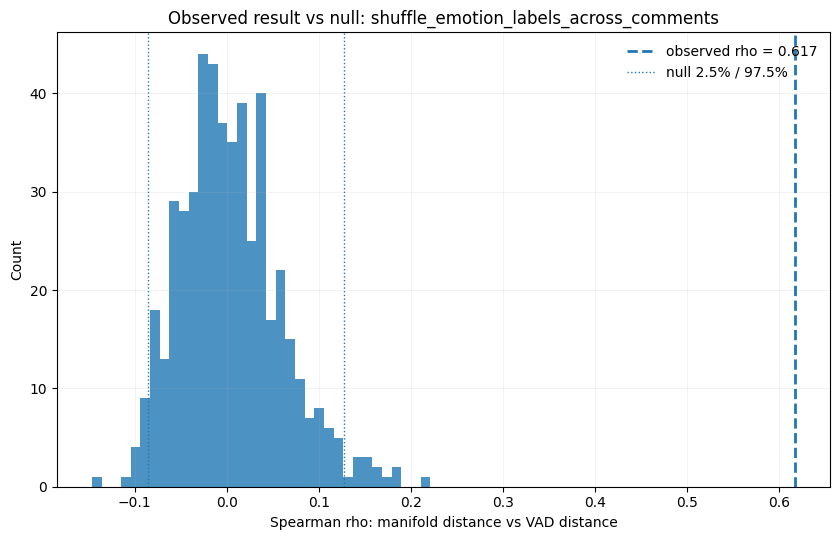

Saved: D:\pyprojects\m4r\new_plots\null_controls\hist_shuffle_emotion_labels_across_comments_cosine_VAD.png


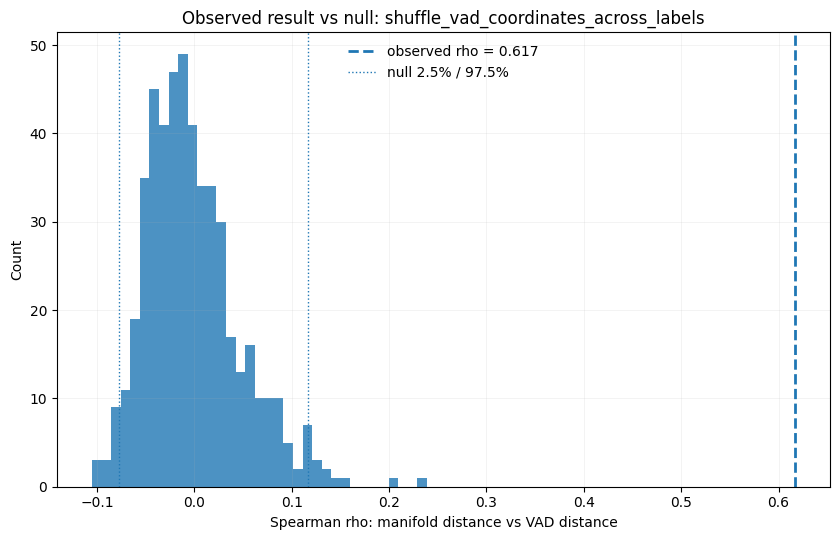

Saved: D:\pyprojects\m4r\new_plots\null_controls\hist_shuffle_vad_coordinates_across_labels_cosine_VAD.png


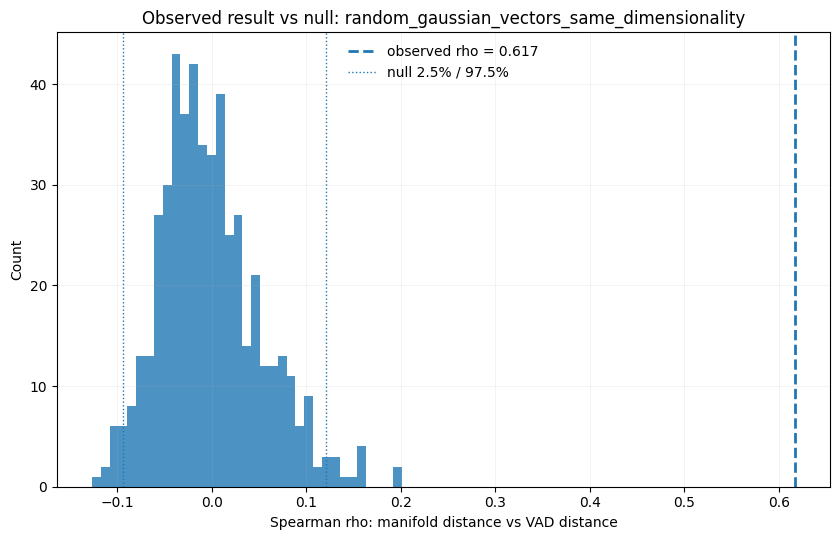

Saved: D:\pyprojects\m4r\new_plots\null_controls\hist_random_gaussian_vectors_same_dimensionality_cosine_VAD.png


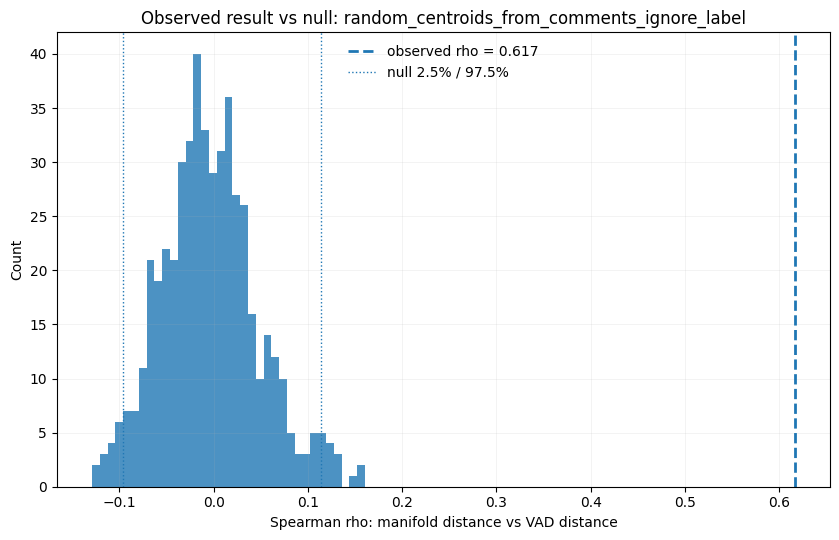

Saved: D:\pyprojects\m4r\new_plots\null_controls\hist_random_centroids_from_comments_ignore_label_cosine_VAD.png


In [10]:
# =========================
# Plot: one histogram per null model
# =========================

safe_distance_name = MANIFOLD_DISTANCE.replace("/", "_")
safe_truth_name = GROUND_TRUTH_SPACE.replace("/", "_")

for null_name, group in null_df.groupby("null_model", sort=False):
    vals = group["spearman_rho"].dropna().to_numpy()
    
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.hist(vals, bins=35, alpha=0.8)
    ax.axvline(observed_rho, linestyle="--", linewidth=2, label=f"observed rho = {observed_rho:.3f}")
    ax.axvline(np.quantile(vals, 0.025), linestyle=":", linewidth=1, label="null 2.5% / 97.5%")
    ax.axvline(np.quantile(vals, 0.975), linestyle=":", linewidth=1)
    
    ax.set_title(f"Observed result vs null: {null_name}")
    ax.set_xlabel("Spearman rho: manifold distance vs VAD distance")
    ax.set_ylabel("Count")
    ax.legend(frameon=False)
    ax.grid(True, linewidth=0.4, alpha=0.25)
    fig.tight_layout()
    
    out_file = OUT_DIR / f"hist_{null_name}_{safe_distance_name}_{safe_truth_name}.png"
    fig.savefig(out_file, dpi=220)
    plt.show()
    plt.close(fig)
    
    print("Saved:", out_file)


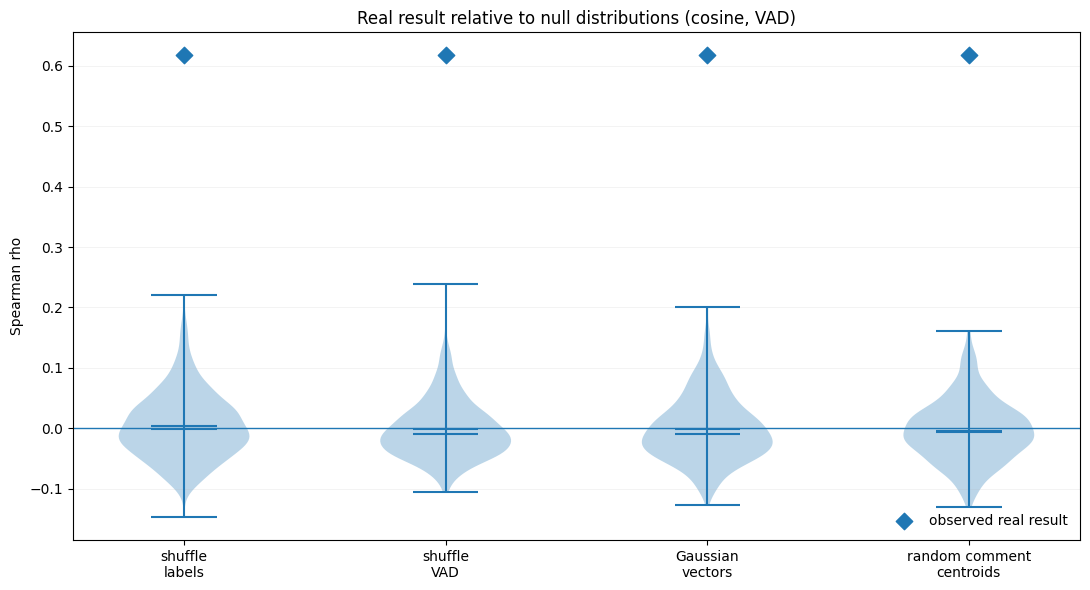

Saved: D:\pyprojects\m4r\new_plots\null_controls\violin_null_controls_cosine_VAD.png


In [11]:
# =========================
# Plot: combined violin plot
# =========================

null_names = list(null_df["null_model"].drop_duplicates())
data = [null_df.loc[null_df["null_model"].eq(name), "spearman_rho"].dropna().to_numpy() for name in null_names]

fig, ax = plt.subplots(figsize=(11, 6))
ax.violinplot(data, showmeans=True, showmedians=True)

x_positions = np.arange(1, len(null_names) + 1)
ax.scatter(x_positions, [observed_rho] * len(null_names), marker="D", s=70, label="observed real result")

ax.set_xticks(x_positions)
ax.set_xticklabels(
    [
        "shuffle\nlabels",
        "shuffle\nVAD",
        "Gaussian\nvectors",
        "random comment\ncentroids",
    ],
    rotation=0,
)
ax.set_ylabel("Spearman rho")
ax.set_title(f"Real result relative to null distributions ({MANIFOLD_DISTANCE}, {GROUND_TRUTH_SPACE})")
ax.axhline(0, linewidth=1)
ax.legend(frameon=False)
ax.grid(True, axis="y", linewidth=0.4, alpha=0.25)
fig.tight_layout()

violin_path = OUT_DIR / f"violin_null_controls_{safe_distance_name}_{safe_truth_name}.png"
fig.savefig(violin_path, dpi=220)
plt.show()
plt.close(fig)

print("Saved:", violin_path)


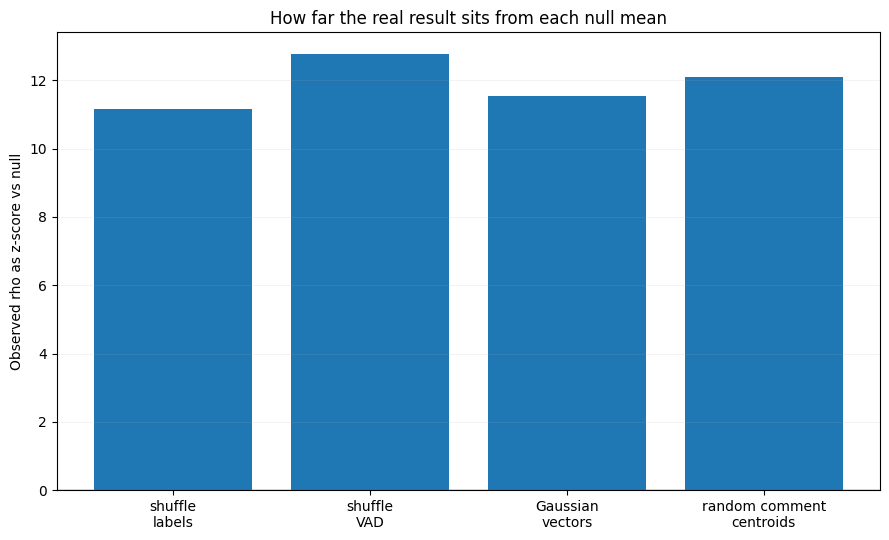

Saved: D:\pyprojects\m4r\new_plots\null_controls\zscore_vs_null_controls_cosine_VAD.png


,null_model,observed_spearman_rho,null_mean,null_std,z_vs_null,observed_percentile_vs_null,empirical_p_greater_equal_observed,empirical_p_abs_greater_equal_abs_observed
0,shuffle_emotion_labels_across_comments,0.616798,0.004116,0.054923,11.155343,100.0,0.001996,0.001996
1,shuffle_vad_coordinates_across_labels,0.616798,-0.001549,0.048426,12.768956,100.0,0.001996,0.001996
2,random_gaussian_vectors_same_dimensionality,0.616798,-0.001177,0.053548,11.540629,100.0,0.001996,0.001996
3,random_centroids_from_comments_ignore_label,0.616798,-0.003651,0.051321,12.089488,100.0,0.001996,0.001996


In [12]:
# =========================
# Plot: null z-score style summary
# =========================

plot_df = summary_df.copy()
plot_df["z_vs_null"] = (plot_df["observed_spearman_rho"] - plot_df["null_mean"]) / plot_df["null_std"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(plot_df))
ax.bar(x, plot_df["z_vs_null"])

ax.set_xticks(x)
ax.set_xticklabels(
    [
        "shuffle\nlabels",
        "shuffle\nVAD",
        "Gaussian\nvectors",
        "random comment\ncentroids",
    ],
)
ax.axhline(0, linewidth=1)
ax.set_ylabel("Observed rho as z-score vs null")
ax.set_title("How far the real result sits from each null mean")
ax.grid(True, axis="y", linewidth=0.4, alpha=0.25)
fig.tight_layout()

z_path = OUT_DIR / f"zscore_vs_null_controls_{safe_distance_name}_{safe_truth_name}.png"
fig.savefig(z_path, dpi=220)
plt.show()
plt.close(fig)

print("Saved:", z_path)
plot_df[[
    "null_model",
    "observed_spearman_rho",
    "null_mean",
    "null_std",
    "z_vs_null",
    "observed_percentile_vs_null",
    "empirical_p_greater_equal_observed",
    "empirical_p_abs_greater_equal_abs_observed",
]]


## How to interpret this without accidentally lying to yourself

Use the **random comment centroid** null as the harshest check. If the real score beats Gaussian noise but not random centroids sampled from real comments, then your result may mostly reflect generic embedding geometry or averaging effects rather than emotion-label structure.

Use **shuffle VAD coordinates** to test whether the affective ordering of labels matters.

Use **shuffle emotion labels across comments** to test whether the comment embeddings actually carry label-specific structure.

A decent result should usually have the observed Spearman rho near or beyond the upper tail of all four nulls, especially the random-comment-centroid null. If it only beats the weak nulls, the result needs a more modest write-up, because the universe punishes overclaiming eventually.
